# 因子分析 — alphalens

数据来源：zer0share 本地 Parquet

> **收益率口径说明**：A股 T+1 制度下，T 日收盘计算的因子最早在 T+1 开盘才能建仓。  
> `open_t1`（默认）：以 T+1 开盘为买入价、T+N+1 开盘为卖出价，即 `open[T+N+1] / open[T+1] - 1`。  
> `close_t0`：alphalens 原始口径 `close[T+N] / close[T] - 1`，不考虑 T+1 限制，仅供对比。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import alphalens
from zer0share.api import LocalPro

# 中文字体
plt.rcParams['font.family'] = 'WenQuanYi Micro Hei'
plt.rcParams['axes.unicode_minus'] = False

# zer0share 数据目录（相对 notebook 位置）
DATA_DIR = Path('../..') / 'zer0share' / 'data'
pro = LocalPro(DATA_DIR)

START = '20160101'
END   = '20260401'

print(f'数据目录: {DATA_DIR.resolve()}')

数据目录: /data/zer0share/data


In [2]:
# ── 配置 ───────────────────────────────────────────────────────────────────
# 收益率口径
# "open_t1"  T+1 开盘买入 → T+N+1 开盘卖出  open[T+N+1] / open[T+1] - 1
# "close_t0" T   收盘买入 → T+N   收盘卖出  close[T+N]  / close[T]  - 1  (alphalens 默认)
RETURN_TYPE = "open_t1"
PERIODS     = (1, 5, 10)

# 待检验因子（zer0factor storage 中的名称）
FACTOR_NAME = "z_neu_daily_return"

## 1. 加载日线数据

In [3]:
# 加载全市场日线（前复权开盘价 + 收盘价 + pct_chg）
daily = pro.daily(start_date=START, end_date=END)
print(f'行数: {len(daily):,}  股票数: {daily["ts_code"].nunique():,}')
daily.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

行数: 10,532,931  股票数: 5,733


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000001.SZ,20160104,12.00,12.03,11.23,11.33,11.99,-0.66,-5.50,563497.87,660376.1531
1,000001.SZ,20160105,11.27,11.57,11.15,11.40,11.33,0.07,0.62,663269.95,755531.3537
2,000001.SZ,20160106,11.42,11.56,11.39,11.53,11.40,0.13,1.14,515706.44,591698.5204
3,000001.SZ,20160107,11.41,11.41,10.91,10.94,11.53,-0.59,-5.12,174761.10,194869.4935
4,000001.SZ,20160108,11.21,11.29,10.90,11.12,10.94,0.18,1.65,747527.58,831334.5462


In [4]:
from zer0factor.config import load_config
from zer0factor.storage import FactorStorage

PROJECT_ROOT = Path('../').resolve() 

cfg     = load_config(PROJECT_ROOT / 'config/settings.toml')
storage = FactorStorage(PROJECT_ROOT / cfg.factor_dir, PROJECT_ROOT / cfg.db_path)

factor_raw = storage.read(FACTOR_NAME, start_date=START, end_date=END)
print(f'因子: {FACTOR_NAME}  行数: {len(factor_raw):,}')
factor_raw.head()

因子: z_neu_daily_return  行数: 8,914,170


,trade_date,ts_code,value
0,20160105,000001.SZ,-0.011080
1,20160105,000002.SZ,-0.255872
2,20160105,000004.SZ,-0.867900
3,20160105,000006.SZ,-0.560472
4,20160105,000007.SZ,0.100713


## 2. 构建价格矩阵与因子

In [5]:
daily['date'] = pd.to_datetime(daily['trade_date'], format='%Y%m%d')
daily = daily[(daily['pct_chg'].notna()) & (daily['vol'] > 0)]

# 价格矩阵
# open_t1:  shift(-1) 让 alphalens 在 T 处读到 open[T+1]
#           forward_return[T] = prices[T+N] / prices[T] - 1
#                             = open[T+N+1] / open[T+1] - 1  ✓
if RETURN_TYPE == 'open_t1':
    prices = daily.pivot(index='date', columns='ts_code', values='open').shift(-1)
else:  # close_t0
    prices = daily.pivot(index='date', columns='ts_code', values='close')

# 因子：从 storage 读取，转为 alphalens 要求的 MultiIndex (date, asset)
factor = (
    factor_raw
    .assign(date=pd.to_datetime(factor_raw['trade_date'].astype(str), format='%Y%m%d'))
    .set_index(['date', 'ts_code'])['value']
    .rename_axis(['date', 'asset'])
)

print(f'价格矩阵: {prices.shape}  收益率口径: {RETURN_TYPE}')
print(f'因子: {FACTOR_NAME}  长度: {len(factor):,}')

价格矩阵: (2487, 5733)  收益率口径: open_t1
因子: z_neu_daily_return  长度: 8,914,170


In [6]:
factor.head()

date        asset    
2016-01-05  000001.SZ   -0.011080
            000002.SZ   -0.255872
            000004.SZ   -0.867900
            000006.SZ   -0.560472
            000007.SZ    0.100713
Name: value, dtype: float64

## 3. alphalens 因子清洗

In [7]:
factor_data = alphalens.utils.get_clean_factor_and_forward_returns(
    factor,
    prices,
    quantiles=10,
    periods=PERIODS,
    max_loss=0.35,
)
print(f'清洗后样本: {len(factor_data):,}')
factor_data.head()

/data/zer0factor/.venv/lib/python3.11/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/data/zer0factor/.venv/lib/python3.11/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/data/zer0factor/.venv/lib/python3.11/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 

Dropped 0.6% entries from factor data: 0.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
清洗后样本: 8,861,021


1D        5D       10D    factor  factor_quantile
date       asset                                                             
2016-01-05 000001.SZ -0.000876 -0.046410 -0.063047 -0.011080                6
           000004.SZ -0.002591 -0.170984 -0.153368 -0.867900                2
           000006.SZ  0.006958 -0.152087 -0.143141 -0.560472                4
           000008.SZ -0.019108 -0.121019 -0.120109  1.050639                9
           000009.SZ -0.012110 -0.165711 -0.165073 -0.742402                3

## 4. 因子评估报告

IC 统计
             1D      5D     10D
Metric                         
IC Mean  -0.024  -0.020  -0.015
IC Std    0.085   0.078   0.070
ICIR     -0.285  -0.256  -0.209
t-stat  -14.170 -12.720 -10.385
IC>0 %   37.278  40.388  42.528

多空价差（高分组 - 低分组）
1D    -10.19
5D    -40.34
10D   -45.41



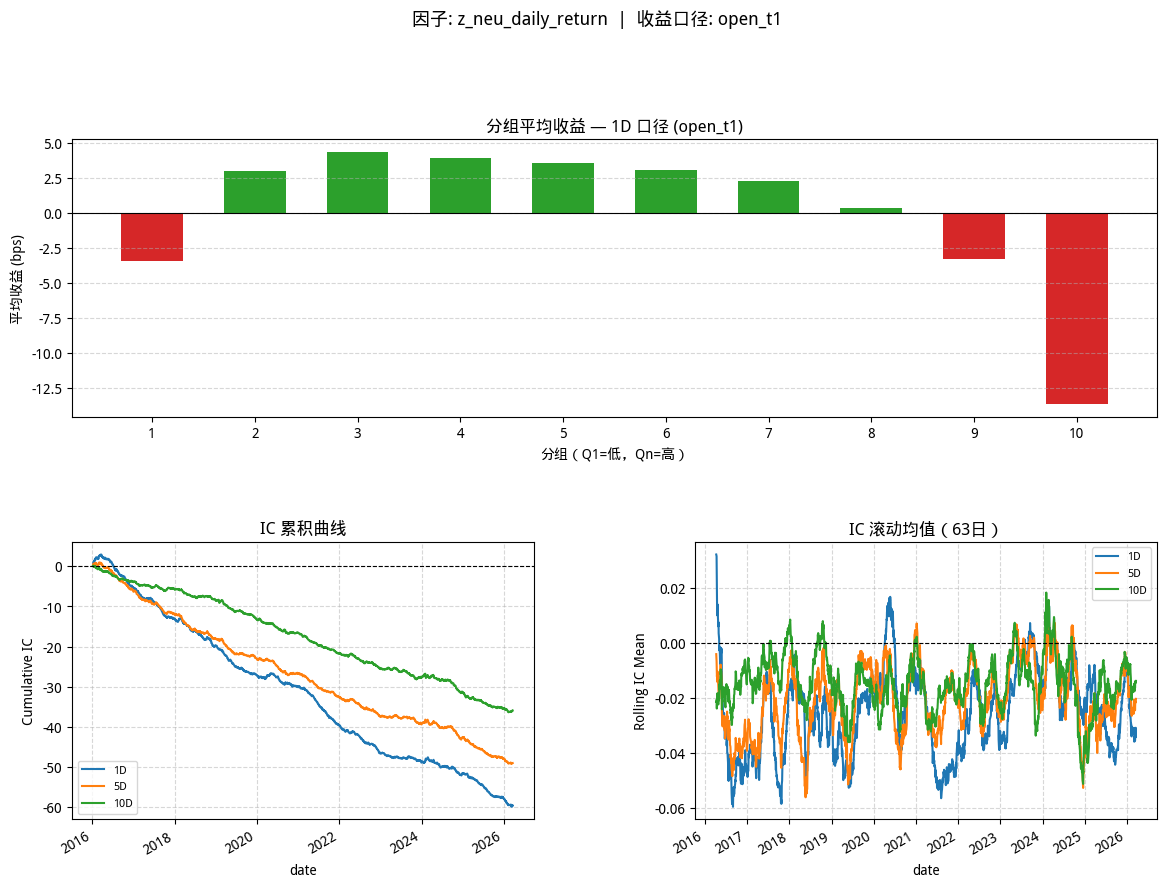

In [8]:
import matplotlib.gridspec as gridspec
import alphalens.performance as perf
import warnings
warnings.filterwarnings('ignore')

# ── 计算核心指标 ───────────────────────────────────────────────────────────
ic         = perf.factor_information_coefficient(factor_data)
ic_summary = perf.mean_information_coefficient(factor_data)
mean_ret, _ = perf.mean_return_by_quantile(factor_data, by_date=False)

# ── IC 摘要表 ─────────────────────────────────────────────────────────────
ic_stats = pd.DataFrame({
    'IC Mean':  ic.mean(),
    'IC Std':   ic.std(),
    'ICIR':     ic.mean() / ic.std(),
    't-stat':   (ic.mean() / ic.std() * (len(ic) ** 0.5)),
    'IC>0 %':   (ic > 0).mean() * 100,
}).T.rename_axis('Metric')
print('IC 统计')
print(ic_stats.round(3).to_string())
print()

# ── 多空价差摘要 ──────────────────────────────────────────────────────────
periods = mean_ret.columns.tolist()
q_max   = mean_ret.index.max()
q_min   = mean_ret.index.min()
spread  = mean_ret.loc[q_max] - mean_ret.loc[q_min]
spread_bps = (spread * 10_000).rename('多空价差 (bps)')
print('多空价差（高分组 - 低分组）')
print(spread_bps.round(2).to_string())
print()

# ── 图表 ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. 分组平均收益柱状图（1D）
ax1 = fig.add_subplot(gs[0, :])
ret_1d = mean_ret.iloc[:, 0] * 10_000
colors = ['#d62728' if v < 0 else '#2ca02c' for v in ret_1d]
ax1.bar(ret_1d.index.astype(str), ret_1d.values, color=colors, width=0.6)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('分组（Q1=低，Qn=高）')
ax1.set_ylabel('平均收益 (bps)')
ax1.set_title(f'分组平均收益 — {periods[0]} 口径 ({RETURN_TYPE})')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 2. IC 累积曲线
ax2 = fig.add_subplot(gs[1, 0])
for col in ic.columns:
    ic[col].cumsum().plot(ax=ax2, label=str(col))
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('IC 累积曲线')
ax2.set_ylabel('Cumulative IC')
ax2.legend(fontsize=8)
ax2.grid(linestyle='--', alpha=0.5)

# 3. IC 滚动均值（63日）
ax3 = fig.add_subplot(gs[1, 1])
for col in ic.columns:
    ic[col].rolling(63).mean().plot(ax=ax3, label=str(col))
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_title('IC 滚动均值（63日）')
ax3.set_ylabel('Rolling IC Mean')
ax3.legend(fontsize=8)
ax3.grid(linestyle='--', alpha=0.5)

fig.suptitle(f'因子: {FACTOR_NAME}  |  收益口径: {RETURN_TYPE}', fontsize=13, y=1.01)
plt.show()